## **External Ligand Curation**

### **Imports**

In [53]:
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import RDLogger
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### **Configuration**

In [54]:
target = 'car' # 'ahr', 'car', 'pxr'


In [ ]:
import os
from pathlib import Path

# Define xenotox as base directory
BASE_DIR = Path(f"{os.getcwd()}/..").resolve()

os.makedirs(f"{BASE_DIR}/ext_ligands/{target}", exist_ok=True)

### **Load data**

In [56]:
import pandas as pd
outpath = f"{BASE_DIR}/ext_ligands/{target}/ext_datatable_all_{target}.csv"
csv = pd.read_csv(outpath)
selected_columns = ['SMILES', 'Agonist_Activity']
df = csv[selected_columns]
df['Agonist_Activity'] = df['Agonist_Activity'].replace('active agonist', 'active')
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SMILES            88 non-null     object
 1   Agonist_Activity  88 non-null     object
dtypes: object(2)
memory usage: 1.5+ KB


,SMILES,Agonist_Activity
0,C1=CC(=CC=C1C2=C(N3C=CSC3=N2)/C=N/OCC4=CC(=C(C...,Active
1,C1=CC(=CC=C1C2=C(N3C=COC3=N2)/C=N/OCC4=CC(=C(C...,Active
2,C1=CC=C2C(=C1)C=CC=C2C3=C(N4C=CSC4=N3)/C=N/OCC...,Active
3,C1=CC=C2C=C(C=CC2=C1)C3=C(N4C=COC4=N3)/C=N/OCC...,Active
4,C1=CC=C2C=C(C=CC2=C1)C3=C(N4C=COC4=N3)/C=N/OCC...,Active
5,C1=CC=C2C=C(C=CC2=C1)C3=C(N4C=COC4=N3)/C=N/OCC...,Active
6,CC(C)(C)C1=CC=C(C=C1)C2=C(N3C=CSC3=N2)/C=N/OCC...,Active
7,CC1=CC=C(C=C1)C2=C(N3C=CSC3=N2)/C=N/OCC4=CC(=C...,Active
8,C1=CC(=CC=C1C2=C(N3C=CSC3=N2)/C=N/OCC4=CC(=C(C...,Active
9,C1CCC(CC1)C2=CC=C(C=C2)C3=C(N4C=CSC4=N3)/C=N/O...,Unspecified


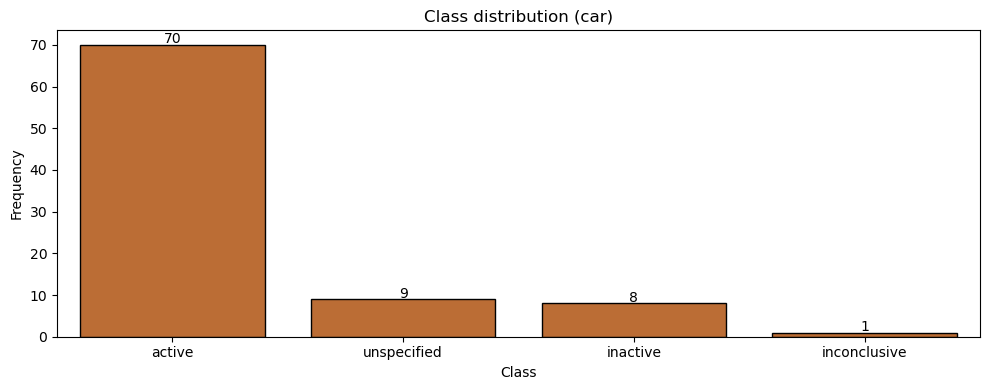

In [ ]:
df['Agonist_Activity'] = df['Agonist_Activity'].str.lower()
activity_col = "Agonist_Activity"
plt.figure(figsize=(10, 4))
ax = sns.countplot(x=activity_col, data=df,
                   edgecolor='black', color='chocolate')
plt.title(f"Class distribution ({target})")
plt.xlabel("Class")
plt.ylabel("Frequency")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        xytext=(0, -1),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

### **Curation**


In [59]:
RDLogger.DisableLog("rdApp.*")

SMILES_COL = "SMILES"

# =============================================================================
# INITIALIZATION
# =============================================================================
df_qsar = df.copy()
total_initial = len(df_qsar)
df_qsar["SMILES_raw"] = df_qsar[SMILES_COL]

curation_report = []
std_report = []

def add_report(step, desc, before, after):
    rem = before - after
    pct = round(rem / before * 100, 2) if before else 0
    curation_report.append({
        "Step": step,
        "Description": desc,
        "Entries_before": before,
        "Entries_after": after,
        "Removed": rem,
        "Removed_%": pct
    })

# =============================================================================
# STEP 1 – SEMANTIC FILTERING
# =============================================================================

before = len(df_qsar)

mask = (
    df_qsar["Agonist_Activity"].str.lower().isin(["active", "inactive"])
)

df_qsar = df_qsar[mask].reset_index(drop=True)

print("Actives:", (df_qsar["Agonist_Activity"] == "active").sum())
print("Inactives:", (df_qsar["Agonist_Activity"] == "inactive").sum())

add_report(1, "Activity filtering", before, len(df_qsar))

# =============================================================================
# STEP 2 – SMILES PARSING
# =============================================================================
before = len(df_qsar)

# Drop rows where SMILES is NaN
df_qsar.dropna(subset=[SMILES_COL], inplace=True)
df_qsar = df_qsar.reset_index(drop=True) # Reset index after dropping rows
# Map SMILES to RDKit molecules.
df_qsar["mol"] = df_qsar[SMILES_COL].map(Chem.MolFromSmiles)
# Filter valid rows
df_qsar = df_qsar[df_qsar["mol"].notna()].reset_index(drop=True)

add_report(2, "SMILES parsing", before, len(df_qsar))

# =============================================================================
# STEP 3 – ORGANIC FILTER
# =============================================================================
before = len(df_qsar)

def is_organic(mol):
    return any(a.GetAtomicNum() == 6 for a in mol.GetAtoms())

df_qsar = df_qsar[df_qsar["mol"].map(is_organic)].reset_index(drop=True)

add_report(3, "Filtering non-organic molecules", before, len(df_qsar))

# =============================================================================
# STEP 4 – STANDARDIZATION
# =============================================================================
mols = df_qsar["mol"]

def smiles(m):
    return Chem.MolToSmiles(m, canonical=True)

def report_changes(tag, before, after):
    chg = (before.map(smiles) != after.map(smiles))
    std_report.append({
        "Substep": tag,
        "Molecules": len(before),
        "Changed": chg.sum(),
        "Changed_%": round(chg.mean() * 100, 2)
    })

# 4.1 Normalize
m_norm = mols.map(rdMolStandardize.Normalize)
report_changes("Normalize", mols, m_norm)

# 4.2 Fragment parent (salt stripping)
m_frag = m_norm.map(rdMolStandardize.FragmentParent)
report_changes("FragmentParent", m_norm, m_frag)

# 4.3 Uncharge
uncharger = rdMolStandardize.Uncharger()
m_unch = m_frag.map(uncharger.uncharge)
report_changes("Uncharger", m_frag, m_unch)

# 4.4 Canonical tautomer
te = rdMolStandardize.TautomerEnumerator()
m_std = m_unch.map(te.Canonicalize)
report_changes("TautomerCanonical", m_unch, m_std)

df_qsar["mol_std"] = m_std

add_report(
    4,
    "Structural standardization",
    len(df_qsar),
    len(df_qsar)
)

# =============================================================================
# STEP 5 – CANONICAL SMILES (FROM STANDARDIZED MOL)
# =============================================================================
before = len(df_qsar)

df_qsar[SMILES_COL] = df_qsar["mol_std"].map(
    lambda m: Chem.MolToSmiles(m, canonical=True)
)

df_qsar = df_qsar[~df_qsar[SMILES_COL].str.contains(r"\*", na=False)]
add_report(5, "Canonical SMILES generation", before, len(df_qsar))

# =============================================================================
# STEP 6 – DEDUPLICATION (FINAL)
# =============================================================================
before = len(df_qsar)

df_qsar = df_qsar.drop_duplicates(subset=[SMILES_COL]).reset_index(drop=True)

add_report(6, "Deduplication by standardized SMILES", before, len(df_qsar))

# =============================================================================
# FINALIZATION AND SUMMARY
# =============================================================================
df_qsar.drop(columns=["mol", "mol_std"], inplace=True)

add_report(7, "Summary", total_initial, len(df_qsar))

curation_report_df = pd.DataFrame(curation_report)
std_report_df = pd.DataFrame(std_report)



Actives: 70
Inactives: 8


In [ ]:
# =============================================================================
# SAVE CSV
# =============================================================================
df_qsar.to_csv(f'{BASE_DIR}/ext_ligands/{target}/ext_{target}_ligands.csv', index=False)
curation_report_df.to_csv(f'{BASE_DIR}/ext_ligands/{target}/ext_{target}_curation_report.csv', index=False)
std_report_df.to_csv(f'{BASE_DIR}/ext_ligands/{target}/ext_{target}_standarization_report.csv', index=False)

In [61]:
curation_report_df

,Step,Description,Entries_before,Entries_after,Removed,Removed_%
0,1,Activity filtering,88,78,10,11.36
1,2,SMILES parsing,78,78,0,0.00
2,3,Filtering non-organic molecules,78,78,0,0.00
3,4,Structural standardization,78,78,0,0.00
4,5,Canonical SMILES generation,78,78,0,0.00
5,6,Deduplication by standardized SMILES,78,77,1,1.28
6,7,Summary,88,77,11,12.50


In [62]:
std_report_df

,Substep,Molecules,Changed,Changed_%
0,Normalize,78,0,0.00
1,FragmentParent,78,0,0.00
2,Uncharger,78,0,0.00
3,TautomerCanonical,78,1,1.28


In [63]:
df_qsar

,SMILES,Agonist_Activity,SMILES_raw
0,Clc1ccc(-c2nc3sccn3c2/C=N/OCc2ccc(Cl)c(Cl)c2)cc1,active,C1=CC(=CC=C1C2=C(N3C=CSC3=N2)/C=N/OCC4=CC(=C(C...
1,Clc1ccc(-c2nc3occn3c2/C=N/OCc2ccc(Cl)c(Cl)c2)cc1,active,C1=CC(=CC=C1C2=C(N3C=COC3=N2)/C=N/OCC4=CC(=C(C...
2,Clc1ccc(CO/N=C/c2c(-c3cccc4ccccc34)nc3sccn23)c...,active,C1=CC=C2C(=C1)C=CC=C2C3=C(N4C=CSC4=N3)/C=N/OCC...
3,Clc1ccc(CO/N=C/c2c(-c3ccc4ccccc4c3)nc3occn23)c...,active,C1=CC=C2C=C(C=CC2=C1)C3=C(N4C=COC4=N3)/C=N/OCC...
4,FC(F)(F)c1ccc(CO/N=C/c2c(-c3ccc4ccccc4c3)nc3oc...,active,C1=CC=C2C=C(C=CC2=C1)C3=C(N4C=COC4=N3)/C=N/OCC...
...,...,...,...
72,CS(=O)(=O)c1ccc(Cn2cc(-c3c(-c4ccc(Cl)cc4)nc4cc...,active,CS(=O)(=O)C1=CC=C(C=C1)CN2C=C(N=N2)C3=C(N=C4N3...
73,Clc1ccc(-c2nc3ccccn3c2-c2nnc(Cc3ccc(Cl)c(Cl)c3...,active,C1=CC2=NC(=C(N2C=C1)C3=NN=C(S3)CC4=CC(=C(C=C4)...
74,Clc1ccc(Cn2cc(-c3c(-c4ccc(Cl)cc4)nc4ccccn34)nn...,active,C1=CC2=NC(=C(N2C=C1)C3=CN(N=N3)CC4=CC=C(C=C4)C...
75,ON=Cc1cc(Cn2cc(-c3c(-c4ccc(Cl)cc4)nc4ccccn34)n...,active,C1=CC2=NC(=C(N2C=C1)C3=CN(N=N3)CC4=CC(=C(C=C4)...


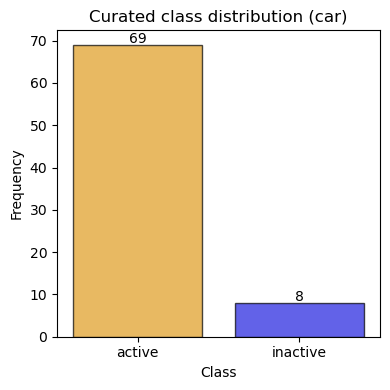

In [64]:
activity_col = "Agonist_Activity"
plt.figure(figsize=(4, 4))

ax = sns.countplot(x=activity_col, data=df_qsar,
                   edgecolor='black', hue=activity_col, palette={'active': 'orange', 'inactive': 'blue'}, alpha=0.7, legend=False)
plt.title(f"Curated class distribution ({target})")
plt.xlabel("Class")
plt.ylabel("Frequency")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        xytext=(0, -1),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

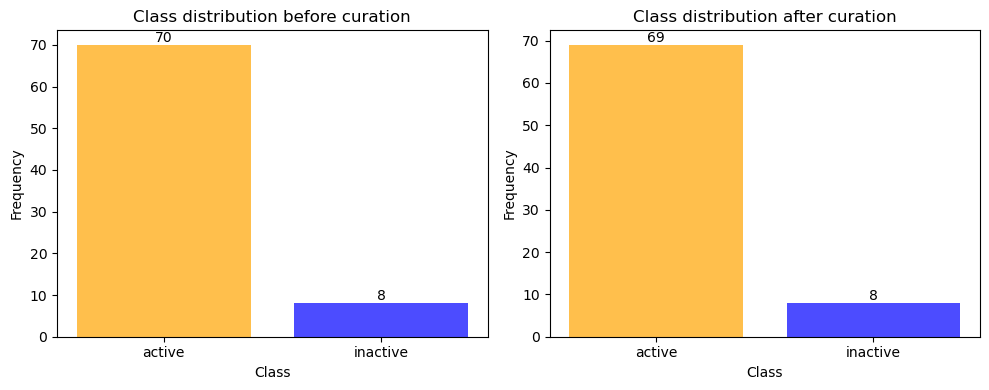

In [65]:
# Comparison of class distributions before and after curation
# Compute counts for before curation (only active and inactive)
before_counts = df[df["Agonist_Activity"].isin(["active", "inactive"])]["Agonist_Activity"].value_counts().sort_index()

# Compute counts for after curation
after_counts = df_qsar["Agonist_Activity"].value_counts().sort_index()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Colors: orange for active, blue for inactive
colors_before = ['orange' if label == 'active' else 'blue' for label in before_counts.index]
colors_after = ['orange' if label == 'active' else 'blue' for label in after_counts.index]

# Before curation
axes[0].bar(before_counts.index, before_counts.values, color=colors_before, alpha=0.7)
axes[0].set_title("Class distribution before curation")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Frequency")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + max(before_counts.values) * 0.01, str(v), ha='center')

# After curation
axes[1].bar(after_counts.index, after_counts.values, color=colors_after, alpha=0.7)
axes[1].set_title("Class distribution after curation")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Frequency")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + max(after_counts.values) * 0.01, str(v), ha='center')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/ext_ligands/{target}/ext_{target}_class_dist_comparison.png', dpi=300)
plt.show()